# Text Preprocessing and Zipf's Law

Tokenizer built from scratch with custom punctuation handling and contraction expansion. Applied to the War and Peace corpus for frequency analysis and Zipf's Law verification.

In [302]:
import re
import string
from collections import Counter
import matplotlib.pyplot as plt
import math
import numpy as np
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /Users/boo/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

### Defining all functions for punctuation and contraction handling

In [305]:
def separate_punct(token): # separating leading and trailing punctuation from tokens
    if not token:
        return []
    if len(token) <= 1 or all(c in string.punctuation for c in token):
        return [token]
    if token in ["'d", "'ll", "'ve", "'re", "'s", "n't", "'m"]: # not separating contraction suffixes like 's or n't
        return [token]    
    tokens = []
    start = 0  # checking for leading punctuation
    while start < len(token) and token[start] in string.punctuation:
        tokens.append(token[start])
        start += 1
    end = len(token) - 1 # checking for trailing punctuation
    trailing = []
    while end >= start and token[end] in string.punctuation:
        trailing.insert(0, token[end])
        end -= 1
    if start <= end: # adding core word
        tokens.append(token[start:end+1])
    tokens.extend(trailing)  # adding trailing punctuations
    return tokens


def expand_contractions(tokens): # expanding contractions based on assignment instructions
    expanded = []
    i = 0
    special_map = {                        # creating mapping for full-word contractions
        "won't": ["will", "not"],
        "can't": ["can", "not"],
        "shan't": ["shall", "not"],
        "let's": ["let", "us"],
        "i'm": ["i", "am"]
    }
    is_words = {"he's", "she's", "it's", "that's", "here's", "there's",     # creating list for is-contractions like it's = it is
                "what's", "when's", "where's", "which's", "who's", "how's"}
    while i < len(tokens):
        tok = tokens[i].strip()
        if not tok:
            i += 1
            continue
        low_tok = tok.lower()
        if low_tok == "n't":      # handling n't
            if expanded:
                prev = expanded[-1]
                if prev == "wo":
                    expanded[-1] = "will"
                elif prev == "ca":
                    expanded[-1] = "can"
                elif prev == "sha":
                    expanded[-1] = "shall"
            expanded.append("not")
            i += 1
            continue
        if low_tok == "'ll":          # handling special suffix contractions
            expanded.append("will")
        elif low_tok == "'ve":
            expanded.append("have")
        elif low_tok == "'d":
            expanded.append("would")
        elif low_tok == "'re":
            expanded.append("are")
        elif low_tok == "'m":
            expanded.append("am")
        elif low_tok == "'s":
            if expanded:
                prev = expanded[-1]
                if (prev.lower() + "'s") in is_words:
                    expanded.append("is")
                elif prev.lower() == "let":
                    expanded[-1] = "let"
                    expanded.append("us")
                else:
                    expanded.append("'s")  # treating as possessive
            else:
                expanded.append("'s")
        elif low_tok in special_map:
            expanded.extend(special_map[low_tok])
        elif low_tok.endswith("n't"):
            base = low_tok[:-3]
            if base:
                expanded.append(base)
                expanded.append("not")
            else:
                expanded.append(low_tok)
        else:
            expanded.append(tok)
        i += 1
    return expanded


def process_toks(nltk_tokens):    # combining punctuation separation and contraction expansion
    punct_fixed = []      # separating punctuation
    for tok in nltk_tokens:
        if tok in ["...", "--"] or all(c in string.punctuation for c in tok):
            punct_fixed.append(tok)
        else:
            punct_fixed.extend(separate_punct(tok))
    expanded = expand_contractions(punct_fixed) # expanding contractions
    normalized = []    # converting tokens to lowercase if not punctuation
    for tok in expanded:
        if tok and not all(c in string.punctuation for c in tok):
            normalized.append(tok.lower())
        else:
            normalized.append(tok)
    return [t for t in normalized if t.strip()]


### Handling sentence fixing functions for each task

In [308]:
def handle_sent_tokenization(sents, task):    # handling NLTK sent_tokenize edge cases where sentences are incorrectly split
    corrected = []
    i = 0
    while i < len(sents):
        curr = sents[i]
        
        #Task 1- NLTK splits a sentence with parenthetical expression
        if task == 'task1' and "wouldn't have" in curr and "wouldn't've or had" in curr:
            if i + 1 < len(sents) and sents[i + 1].strip().startswith("bothered me"):
                curr += " " + sents[i + 1]
                i += 1 # Skipping next since it belongs to current
        
        #Task 2- NLTK splits sentences at quote boundaries incorrectly
        if task == 'task2' and curr.strip().endswith('."'):
            if i + 1 < len(sents) and len(sents[i + 1]) > 0 and sents[i + 1][0].islower():
                curr += ' ' + sents[i + 1].strip()
                i += 1 # skipping next since it's a continuation
        
        corrected.append(curr)
        i += 1
    return corrected

## Testing with custom input

In [311]:
test_sentences = [
    "Let's test this sentence.",
    "He won't do it, and she can't help.",
    "I shouldn't've done that.",
    "It's cold outside, isn't it?",
    "The phone's battery is dead.",
    "She's going to the store. He's not.",
    "That girl's jacket's torn.",
    "E.g., $3.19 is the price. Wait... what?!",
    "Where's the file?",
    "Hello!! Are you okay--really?",
    "\"He's ready,\" she said.",
    "We're sure it'll work."]

print("=== Testing===\n")
for sentence in test_sentences:
    nltk_tokens = word_tokenize(sentence)
    processed_tokens = process_toks(nltk_tokens)
    
    print(f"Original Sentence: {sentence}")
    print(f"NLTK Tokens:       {nltk_tokens}")
    print(f"Processed Tokens:  {processed_tokens}")

=== Testing===

Original Sentence: Let's test this sentence.
NLTK Tokens:       ['Let', "'s", 'test', 'this', 'sentence', '.']
Processed Tokens:  ['let', 'us', 'test', 'this', 'sentence', '.']
Original Sentence: He won't do it, and she can't help.
NLTK Tokens:       ['He', 'wo', "n't", 'do', 'it', ',', 'and', 'she', 'ca', "n't", 'help', '.']
Processed Tokens:  ['he', 'will', 'not', 'do', 'it', ',', 'and', 'she', 'can', 'not', 'help', '.']
Original Sentence: I shouldn't've done that.
NLTK Tokens:       ['I', "shouldn't", "'ve", 'done', 'that', '.']
Processed Tokens:  ['i', 'should', 'not', 'have', 'done', 'that', '.']
Original Sentence: It's cold outside, isn't it?
NLTK Tokens:       ['It', "'s", 'cold', 'outside', ',', 'is', "n't", 'it', '?']
Processed Tokens:  ['it', 'is', 'cold', 'outside', ',', 'is', 'not', 'it', '?']
Original Sentence: The phone's battery is dead.
NLTK Tokens:       ['The', 'phone', "'s", 'battery', 'is', 'dead', '.']
Processed Tokens:  ['the', 'phone', "'s", 'batt

### Creating the core file processing function

In [314]:
def process_file(file_path, task='task1', encoding='utf-8-sig'):
    with open(file_path, 'r', encoding=encoding) as f:
        text = f.read() # reading full text
    paras = re.split(r'\n\s*\n', text.strip())  # counting paragraphs (splitting on double newlines)
    para_count = len([p for p in paras if p.strip()])
    sentences = sent_tokenize(text)  # splitting into sentences
    sentences = handle_sent_tokenization(sentences, task)
    sent_count = len(sentences)
    all_tokens = []
    for sent in sentences:
        tokens = word_tokenize(sent)     # applying nltk tokenization
        processed = process_toks(tokens) # applying our processing rules
        all_tokens.extend(processed)     # collecting all tokens
    all_tokens = [t for t in all_tokens if t.strip()] # filtering out empty tokens
    token_count = len(all_tokens)
    token_freq = Counter(all_tokens) # counting frequency of each token
    unique_count = len(token_freq)
    sorted_freq = sorted(token_freq.items(), key=lambda x: (-x[1], x[0])) # sorting tokens by frequency (desc) and then alphabetically

    return {
        'para_count': para_count,
        'sent_count': sent_count,
        'token_count': token_count,
        'unique_count': unique_count,
        'sorted_freq': sorted_freq
    }


### Displaying results and plotting Zipf's Law

In [317]:
def display_results(stats, output_file, task=None):
    with open(output_file, 'w', encoding='utf-8-sig') as f:
        f.write(f"# of paragraphs: {stats['para_count']}\n")
        f.write(f"# of sentences: {stats['sent_count']}\n")
        f.write(f"# of tokens: {stats['token_count']}\n")
        f.write(f"# of unique tokens: {stats['unique_count']}\n")
        f.write("====================================\n")
        for i, (tok, freq) in enumerate(stats['sorted_freq'], 1):
            f.write(f"{i}: {tok}  {freq}\n")

    print(f"# of paragraphs: {stats['para_count']}")
    print(f"# of sentences: {stats['sent_count']}")
    print(f"# of tokens: {stats['token_count']}")
    print(f"# of unique tokens: {stats['unique_count']}") 
    if task == 'task2': # Plotting Zipf's Law
        freqs = [freq for _, freq in stats['sorted_freq']]
        ranks = range(1, len(freqs) + 1)
        log_freqs = [math.log(f) for f in freqs]

        plt.figure(figsize=(10, 5))
        plt.plot(ranks, log_freqs)
        plt.xlabel("Token Rank")
        plt.ylabel("Log Frequency")
        plt.title("Zipf's Law for Word Frequencies (War and Peace)")
        plt.grid()
        plt.show()

## Tasks execution

sample_2025.txt
# of paragraphs: 8
# of sentences: 31
# of tokens: 567
# of unique tokens: 274
war-and-peace.txt
# of paragraphs: 12169
# of sentences: 32111
# of tokens: 673320
# of unique tokens: 18284


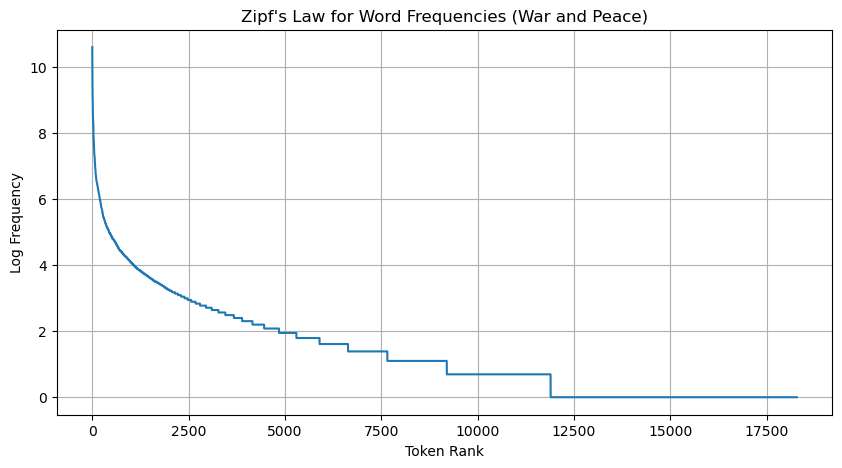

In [320]:
print("====================================")
print("sample_2025.txt")
print("====================================")
task1_stats = process_file("sample_2025.txt", task="task1")
display_results(task1_stats, output_file="output1.txt")


print("====================================")
print("war-and-peace.txt")
print("====================================")
task2_stats = process_file("war-and-peace.txt", task="task2")
display_results(task2_stats, output_file="output2.txt", task="task2")

